In [1]:
import pandas as pd

df_model = pd.read_pickle('nhamcs_clean.pkl')
df_model['RACERETH'] = df_model['RACERETH'].astype('category')
df_model['IMMEDR'] = df_model['IMMEDR'].astype('category')
df_model['PAYTYPER'] = df_model['PAYTYPER'].astype('category')
print(df_model.dtypes)

WAITTIME          object
RACERETH        category
IMMEDR          category
AGE                int16
SEX                 int8
ARREMS            object
PAYTYPER        category
arrival_hour       Int64
dtype: object


In [2]:
df_model['WAITTIME'] = df_model['WAITTIME'].astype('float')

In [3]:
import statsmodels.formula.api as smf

model = smf.ols('WAITTIME ~ C(RACERETH)', data=df_model).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               WAITTIME   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     4.313
Date:                Wed, 24 Jun 2026   Prob (F-statistic):            0.00479
Time:                        22:38:12   Log-Likelihood:                -44109.
No. Observations:                7971   AIC:                         8.823e+04
Df Residuals:                    7967   BIC:                         8.825e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           35.6582      0.914  

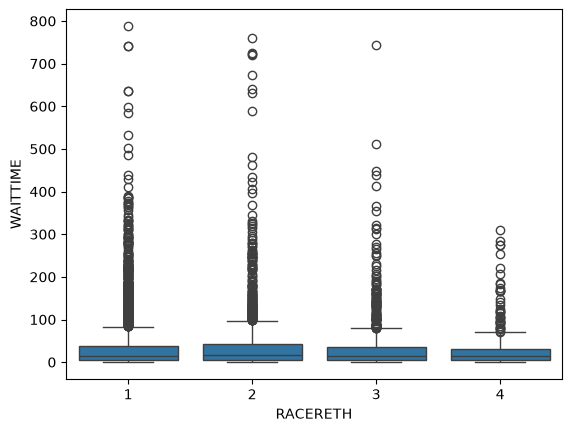

In [4]:
# boxplot: shows distribution by category
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x='RACERETH', y='WAITTIME', data=df_model)
plt.xticks()
plt.show()

In [5]:
# WAITTIME log transformation
import numpy as np
df_model['log_waittime'] = np.log(df_model['WAITTIME'] + 1) # add 1 to avoid log(0)

model_log = smf.ols('log_waittime ~ C(RACERETH)', data=df_model).fit()
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:           log_waittime   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.305
Date:                Wed, 24 Jun 2026   Prob (F-statistic):             0.0193
Time:                        22:38:12   Log-Likelihood:                -13723.
No. Observations:                7971   AIC:                         2.745e+04
Df Residuals:                    7967   BIC:                         2.748e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            2.7684      0.020  

In [6]:
# Cross-tab RACERETH x IMMEDR
from scipy.stats import chi2_contingency

# Row-normalized: distribution of triage levels within each race group
crosstab = pd.crosstab(
    df_model['RACERETH'],
    df_model['IMMEDR'],
    normalize='index'
).round(3) * 100 # as percentages

print('Triage level distribution (%) by race group:')
print(crosstab)

# Chi-square test: are the distributions significantly differrent?
ct_raw = pd.crosstab(df_model['RACERETH'], df_model['IMMEDR'])
chi2, p , dof, expected = chi2_contingency(ct_raw)
print(f'\nChi-square = {chi2:.2f}, df = {dof}, p = {p:.4f}')

Triage level distribution (%) by race group:
IMMEDR      1     2     3     4    5
RACERETH                            
1         1.0  16.7  54.0  25.5  2.8
2         1.7  15.7  48.9  30.3  3.5
3         1.3  12.0  53.2  29.9  3.6
4         2.6  19.1  51.0  26.1  1.2

Chi-square = 55.45, df = 12, p = 0.0000


In [7]:
# Model sequence of RACERETH with different variables
import statsmodels.formula.api as smf

# Model 1 - baseline (race only)
m1 = smf.ols('log_waittime ~ C(RACERETH)', data=df_model).fit()

# Model 2 - add triage urgency
m2 = smf.ols('log_waittime ~ C(RACERETH) + C(IMMEDR)', data=df_model).fit()

# Model 3 - add insurance type
m3 = smf.ols('log_waittime ~ C(RACERETH) + C(IMMEDR) + C(PAYTYPER)', data=df_model).fit()

# Model 4 - full model
m4 = smf.ols(
    'log_waittime ~ C(RACERETH) + C(IMMEDR) + C(PAYTYPER) + AGE + C(SEX) + C(ARREMS) + arrival_hour',
    data=df_model
).fit()

In [8]:
# Coeffecient comparison table
import pandas as pd

race_vars = [c for c in m4.params.index if 'RACERETH' in c]

comparison = pd.DataFrame({
    'M1 (race only)':   m1.params[race_vars],
    'M2 (+ triage)':    m2.params[race_vars],
    'M3 (+ insurance)': m3.params[race_vars],
    'M4 (full)':        m4.params[race_vars],
}).round(4)

print(comparison)
print("\nR^2 across models:")
for name, m in [('M1', m1), ('M2', m2), ('M3', m3), ('M4', m4)]:
    print(f'  {name}: {m.rsquared:.4f}')

comparison_p = pd.DataFrame({
    'M1': m1.pvalues[race_vars],
    'M2': m2.pvalues[race_vars],
    'M3': m3.pvalues[race_vars],
    'M4': m4.pvalues[race_vars],
}).round(4)
print(comparison_p)

                  M1 (race only)  M2 (+ triage)  M3 (+ insurance)  M4 (full)
C(RACERETH)[T.2]         -0.0205        -0.0224           -0.0235    -0.0075
C(RACERETH)[T.3]         -0.1204        -0.1350           -0.1386    -0.1608
C(RACERETH)[T.4]         -0.1269        -0.1137           -0.1220    -0.1271

R^2 across models:
  M1: 0.0012
  M2: 0.0101
  M3: 0.0119
  M4: 0.0324
                      M1      M2      M3      M4
C(RACERETH)[T.2]  0.5858  0.5507  0.5401  0.8429
C(RACERETH)[T.3]  0.0046  0.0014  0.0015  0.0002
C(RACERETH)[T.4]  0.0935  0.1315  0.1060  0.0890


In [9]:
# Hispanic patients waited significiantly shorter in ED than Non-Hispanic White Patients in every model spceification
# tested. After adjusting for triage urgency, insurance type, age, sex, arrival mode, and time of day, Hispanic
# patients' wait times were approx. 14.8% shorter (Beta = -0.161, p=0.0002). Notably, the effect strengthened after
# controlling for triage urgency - suggesting triage does not explain the gap and may itself be a source of differential
# treatment. No significant disparity was observed for Non-Hispanic Black or Non-Hispanic Other patients in this sample.

In [10]:
print(m4.conf_int().loc[race_vars].round(4))

                       0       1
C(RACERETH)[T.2] -0.0820  0.0670
C(RACERETH)[T.3] -0.2458 -0.0758
C(RACERETH)[T.4] -0.2735  0.0194


In [11]:
print(df_model['RACERETH'].value_counts().sort_index())
# limitations: smaller sample size to pool from 2022

RACERETH
1    4491
2    1821
3    1314
4     345
Name: count, dtype: int64


In [12]:
df_model.to_pickle('nhamcs_model.pkl')